In [79]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [80]:
import pandas as pd
df = pd.read_csv("구군별 교통 접근성.csv")

In [81]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


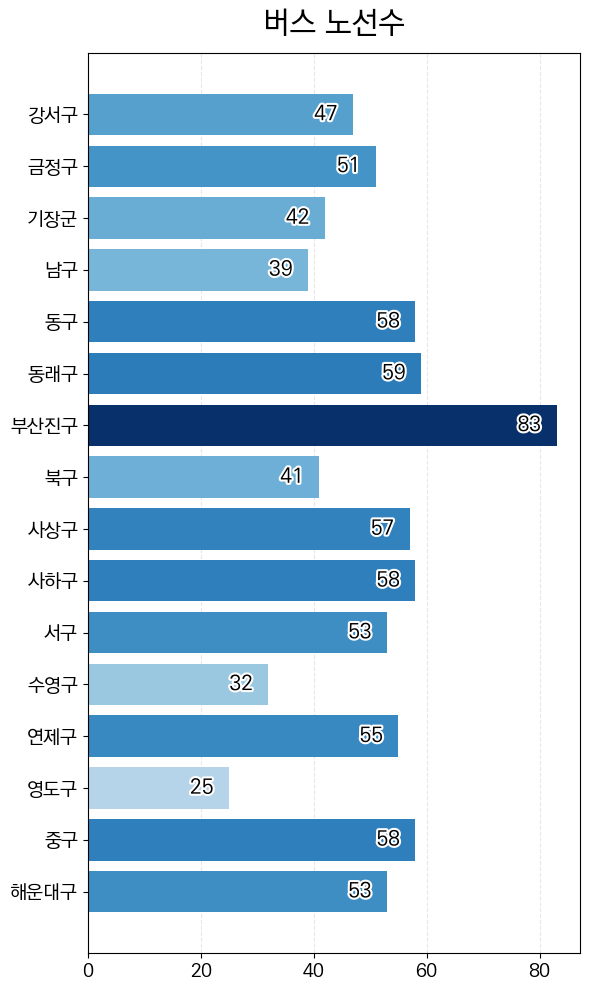

In [18]:
import matplotlib.patheffects as pe

d = df.sort_values("구군", ascending=False)
colors = plt.cm.Blues(d["노선수"] / d["노선수"].max())

fig, ax = plt.subplots(figsize=(6, 10))
bars = ax.barh(d["구군"], d["노선수"], color=colors)

labels = ax.bar_label(
    bars, padding=-28, fontsize=15, color="black", weight="bold"
)

for t in labels:
    t.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ])

ax.grid(axis="x", linestyle="--", alpha=.3)
ax.set_axisbelow(True)

ax.set_title("버스 노선수", fontsize=22, weight="bold", pad=15)
# ax.set_xlabel("노선수", fontsize=16)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()

plt.savefig(
    "버스_노선수.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

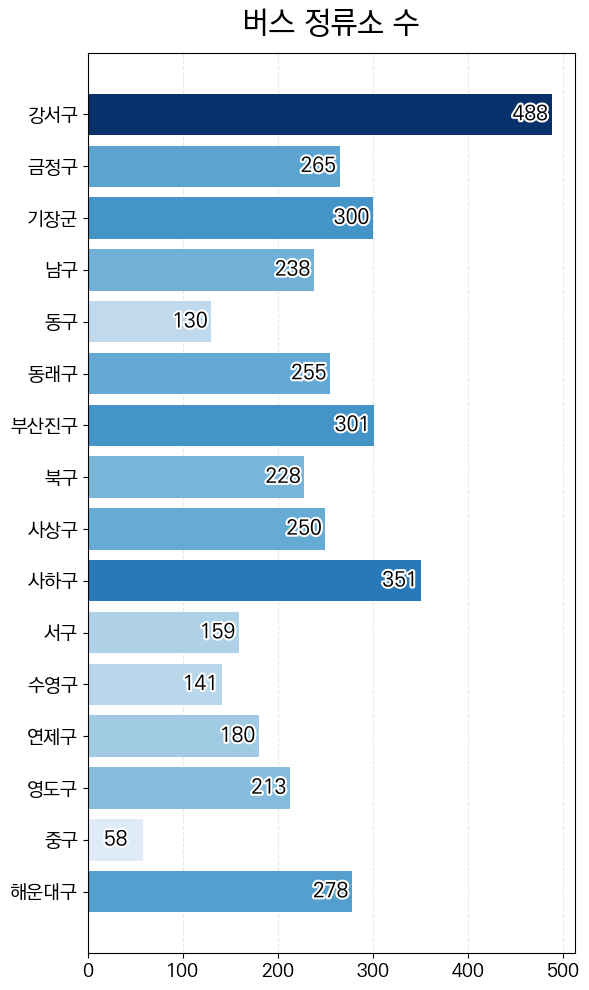

In [19]:
d = df.sort_values("구군", ascending=False)
colors = plt.cm.Blues(d["정류소수"] / d["정류소수"].max())

fig, ax = plt.subplots(figsize=(6, 10))
bars = ax.barh(d["구군"], d["정류소수"], color=colors)

labels = ax.bar_label(
    bars, padding=-28, fontsize=15, color="black", weight="bold"
)

for t in labels:
    t.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ])

ax.grid(axis="x", linestyle="--", alpha=.3)
ax.set_axisbelow(True)
ax.set_title("버스 정류소 수", fontsize=22, weight="bold", pad=15)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.savefig("버스_정류소수.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [86]:
df.loc[df["구군"]=="강서구","지하철역수"] = 9
df.loc[df["구군"]=="기장군","지하철역수"] = 7

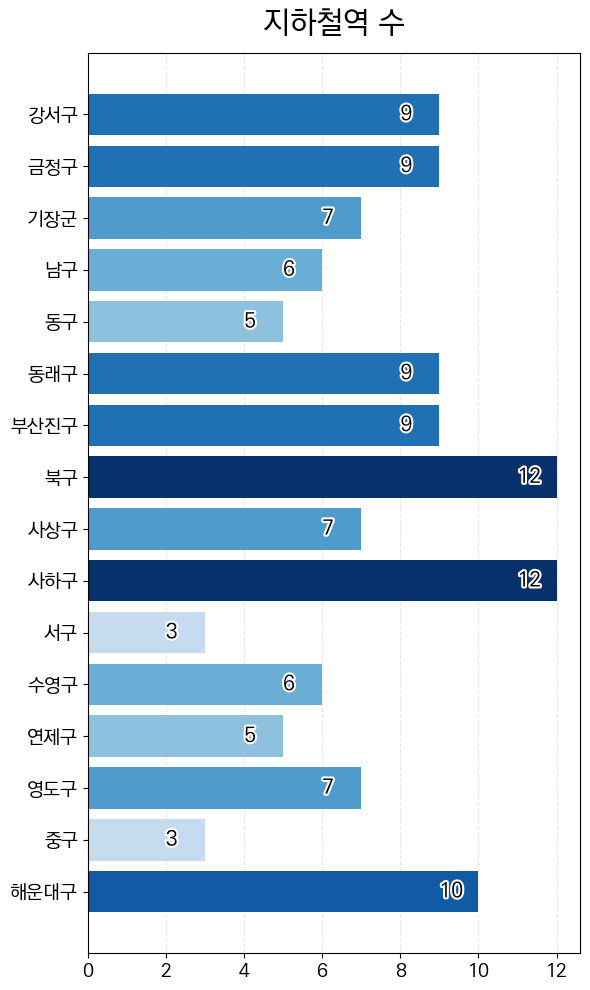

In [87]:
d = df.sort_values("구군", ascending=False)
colors = plt.cm.Blues(d["지하철역수"] / d["지하철역수"].max())

fig, ax = plt.subplots(figsize=(6, 10))
bars = ax.barh(d["구군"], d["지하철역수"], color=colors)

labels = ax.bar_label(
    bars, padding=-28, fontsize=15, color="black", weight="bold"
)

for t in labels:
    t.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ])

ax.grid(axis="x", linestyle="--", alpha=.3)
ax.set_axisbelow(True)
ax.set_title("지하철역 수", fontsize=22, weight="bold", pad=15)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.savefig("지하철역수.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [88]:
import geopandas as gpd

In [89]:
gdf = gpd.read_file("../sigungu/sig.shp", encoding="cp949")
gdf = gdf.set_crs(epsg=5179)
gdf = gdf.to_crs(4326)
gdf = gdf[[i[:2]=="26" for i in gdf["SIG_CD"]]].reset_index(drop=True)

In [90]:
gdf = gdf.merge(df, right_on = "구군", left_on="SIG_KOR_NM")
gdf

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry,구군,노선수,정류소수,지하철역수
0,26110,Jung-gu,중구,"POLYGON ((129.03231 35.11643, 129.03235 35.116...",중구,58,58,3
1,26140,Seo-gu,서구,"MULTIPOLYGON (((129.01542 35.04808, 129.01515 ...",서구,53,159,3
2,26170,Dong-gu,동구,"POLYGON ((129.04264 35.14589, 129.04327 35.145...",동구,58,130,5
3,26200,Yeongdo-gu,영도구,"MULTIPOLYGON (((129.0932 35.03771, 129.09324 3...",영도구,25,213,7
4,26230,Busanjin-gu,부산진구,"POLYGON ((129.04001 35.19981, 129.04033 35.199...",부산진구,83,301,9
5,26260,Dongnae-gu,동래구,"POLYGON ((129.07905 35.22509, 129.0791 35.2250...",동래구,59,255,9
6,26290,Nam-gu,남구,"MULTIPOLYGON (((129.12702 35.09096, 129.12697 ...",남구,39,238,6
7,26320,Buk-gu,북구,"POLYGON ((128.98774 35.20145, 128.98774 35.201...",북구,41,228,12
8,26350,Haeundae-gu,해운대구,"MULTIPOLYGON (((129.13898 35.1586, 129.13963 3...",해운대구,53,278,10
9,26380,Saha-gu,사하구,"MULTIPOLYGON (((128.95195 34.88449, 128.95194 ...",사하구,58,351,12


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 가로로 넓게
fig, ax = plt.subplots(figsize=(18, 11))

gdf.plot(
    ax=ax,
    color="#F3F6F9",
    edgecolor="#8A9BAD",
    linewidth=1
)

xmin, ymin, xmax, ymax = gdf.total_bounds
W, H = xmax-xmin, ymax-ymin

cols = ["노선수", "정류소수", "지하철역수"]
bar_colors = ["#2166AC", "#4393C3", "#66C2A4"]

# 막대 크기도 살짝 축소
max_w = W * .06
bar_h = H * .009   # .005 → .009 막대 두껍게
gap   = H * .014   # .008 → .014 막대 사이 간격 넓게
outline = [
    pe.Stroke(linewidth=3, foreground="white"),
    pe.Normal()
]
offset = {
    "부산진구": (-.025,  .015),
    "동래구":   ( .005,  .025),
    "연제구":   ( .020,  .005),

    "수영구":   ( .020, -.005),  # 좌측 이동

    "동구":     ( .015,  .020),  # 위쪽 이동
    "중구": ( .020, -.025),
    "서구": (-.0, .055),
    "남구":     ( .015,  .005),  # 좌측 + 위쪽 이동
    "영도구":   ( .020, -.015),
}
for _, row in gdf.iterrows():

    p = row.geometry.representative_point()

    dx, dy = offset.get(row["구군"], (0, 0))

    # 위치 보정
    cx = p.x + dx * W
    y0 = p.y + dy * H

    # 막대 전체를 중심점 기준 왼쪽으로 이동
    x0 = cx - max_w * .45

    # 구군명
    name = ax.text(
        x0,
        y0 + H*.014,
        row["구군"],
        ha="left",
        va="bottom",
        fontsize=11,
        weight="bold",
        color="#111",
        zorder=10
    )
    name.set_path_effects(outline)

    # 가로 막대 3개
    for i, (col, c) in enumerate(zip(cols, bar_colors)):

        value = row[col]
        width = value / gdf[col].max() * max_w
        y = y0 - i * gap

        ax.barh(
            y,
            width,
            height=bar_h,
            left=x0,
            color=c,
            edgecolor="white",
            linewidth=.6,
            zorder=5
        )
        txt = ax.text(
            x0 + width + W*.002,  # 막대 끝보다 살짝 오른쪽
            y,
            f"{value}",
            ha="left",
            va="center",
            fontsize=10,
            weight="bold",
            color="#111",
            zorder=10
        )
        txt.set_path_effects(outline)

# 범례
handles = [
    plt.Rectangle((0,0), 1,1, color=c)
    for c in bar_colors
]

ax.legend(
    handles,
    ["노선수", "정류소수", "지하철역수"],
    loc="lower right",
    bbox_to_anchor=(.98, .28),
    frameon=False,
    fontsize=13
)
ax.axis("off")

# 지도 주변 여백 확보
ax.set_xlim(xmin - W*.10, xmax + W*.10)
ax.set_ylim(ymin - H*.04, ymax + H*.04)

plt.tight_layout()

plt.savefig(
    "부산_교통인프라_가로형.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()